# Sentinel Stream — Data exploration & anomaly characterisation

This notebook walks through the synthetic sensor dataset that powers Sentinel Stream and visualises the three families of injected anomalies the detectors are trained to flag: **spikes**, **drift segments**, and **correlated multi-sensor faults**.

It also shows the reconstruction-error signal that drives the autoencoder detector and contrasts it with the Isolation Forest baseline on the same feature space.

## Contents
1. Generate a labelled synthetic dataset
2. Inspect channel distributions and seasonality
3. Visualise the three anomaly flavours
4. Engineer streaming features
5. Score with Isolation Forest and inspect separation
6. Score with the autoencoder (reconstruction error)
7. Compare detector ROC curves

In [1]:
from __future__ import annotations

from datetime import UTC, datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc

from sentinel_stream.data.generator import GeneratorConfig, generate
from sentinel_stream.features.transformer import StreamingFeatureTransformer
from sentinel_stream.models.isolation_forest import IsolationForestDetector

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\ma2mo\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ma2mo\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\ma2mo\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_lo

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\ma2mo\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ma2mo\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\ma2mo\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_lo

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



## 1. Generate a labelled dataset

10,000 one-second readings with 2% anomalies. The seed is fixed so the notebook is reproducible.

In [2]:
df = generate(GeneratorConfig(rows=10_000, anomaly_rate=0.02, seed=11))
df.head()

,timestamp,temperature,pressure,vibration,humidity,is_anomaly
0,2025-01-01 00:00:00,70.023935,101.487412,0.107720,45.222593,0
1,2025-01-01 00:00:01,70.952134,101.181918,0.109093,46.051095,0
2,2025-01-01 00:00:02,70.857927,101.359214,0.142945,45.649104,0
3,2025-01-01 00:00:03,69.643718,101.425788,0.128355,45.032719,0
4,2025-01-01 00:00:04,69.792665,101.054116,0.122971,43.811848,0


In [3]:
print(f"Rows:       {len(df):,}")
print(f"Anomalies:  {df['is_anomaly'].sum():,}  ({df['is_anomaly'].mean():.2%})")
df.describe().T[["mean", "std", "min", "max"]]

Rows:       10,000
Anomalies:  2,799  (27.99%)


,mean,std,min,max
timestamp,2025-01-01 01:23:19.500000,NaN,2025-01-01 00:00:00,2025-01-01 02:46:39
temperature,71.569806,1.78532,51.218872,91.618966
pressure,102.296043,1.5226,100.805678,110.121527
vibration,0.122105,0.08093,0.100001,1.628058
humidity,47.77472,1.967313,41.295332,53.680648
is_anomaly,0.2799,0.448972,0.0,1.0


## 2. Channel distributions and seasonality

Each channel is a sine-modulated baseline plus Gaussian noise. The temperature and humidity channels carry the strongest daily pattern; pressure is nearly flat; vibration is a low-amplitude positive-only channel.

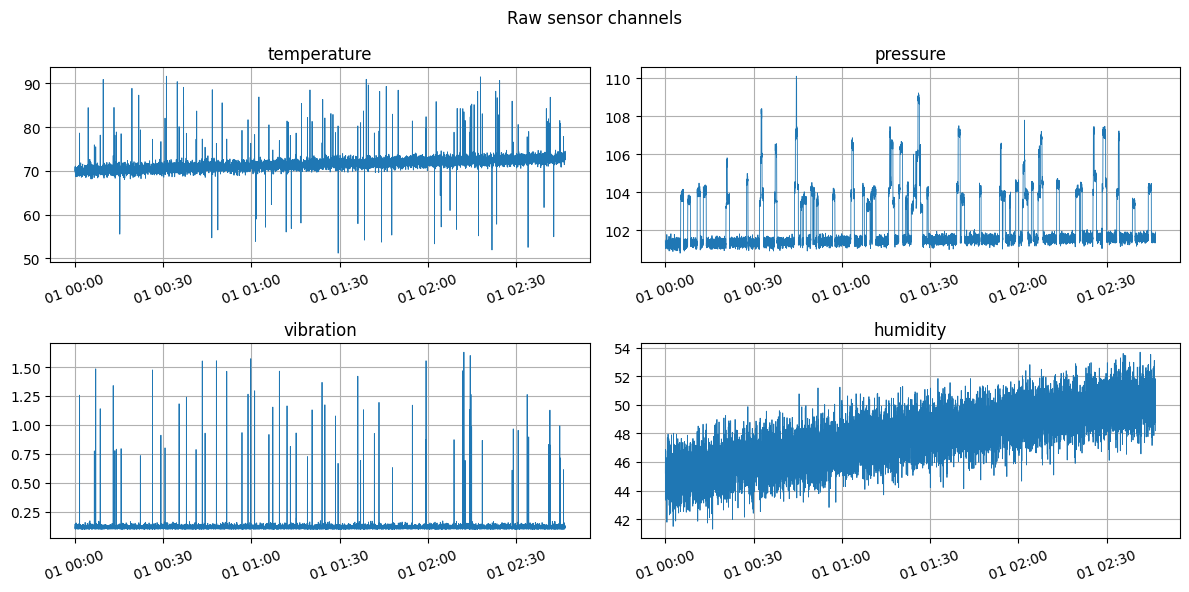

In [4]:
channels = ["temperature", "pressure", "vibration", "humidity"]
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, ch in zip(axes.ravel(), channels):
    ax.plot(df["timestamp"], df[ch], lw=0.6)
    ax.set_title(ch)
    ax.tick_params(axis="x", rotation=20)
fig.suptitle("Raw sensor channels")
fig.tight_layout()

## 3. Three anomaly flavours

Zooming in on a window with anomalies makes it easier to see the qualitatively different failure modes:

- **Spikes** — single-sample temperature outliers
- **Drift segments** — sustained pressure offsets that last 20–80 seconds
- **Correlated faults** — joint vibration + temperature deviations

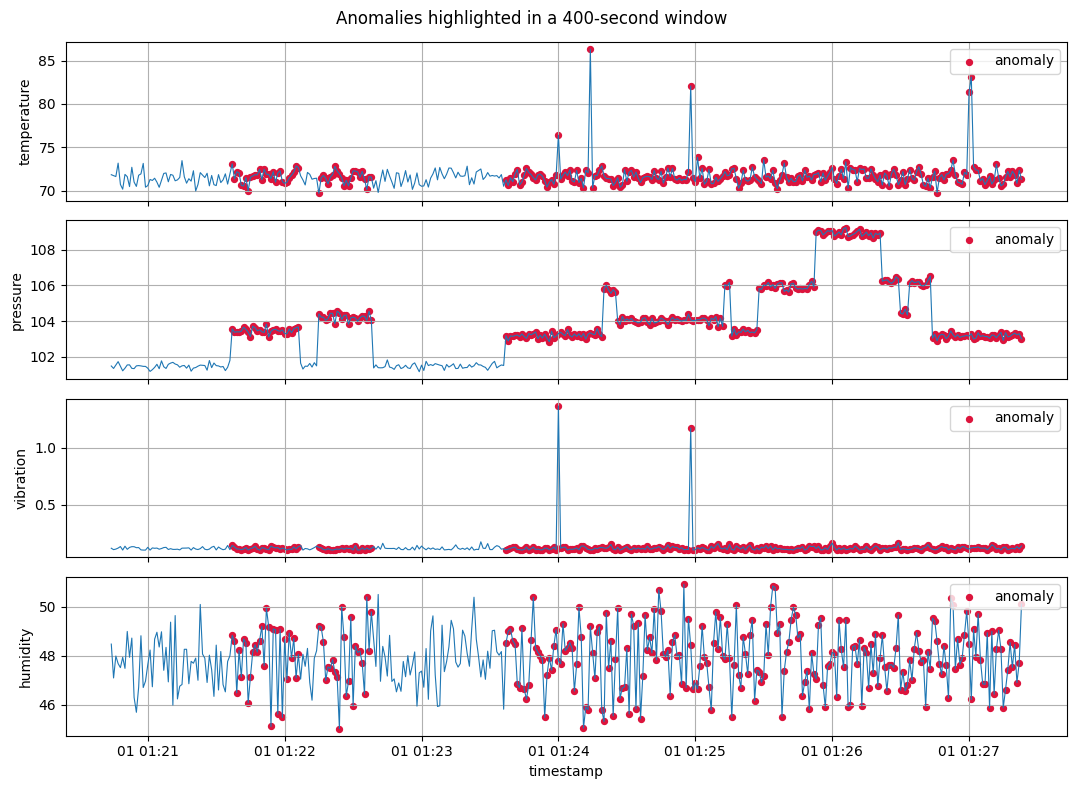

In [5]:
anomaly_idx = df.index[df["is_anomaly"] == 1]
anchor = anomaly_idx[len(anomaly_idx) // 2]
window = df.iloc[max(0, anchor - 200) : anchor + 200]

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(11, 8))
for ax, ch in zip(axes, channels):
    ax.plot(window["timestamp"], window[ch], lw=0.8)
    flagged = window[window["is_anomaly"] == 1]
    ax.scatter(flagged["timestamp"], flagged[ch], color="crimson", s=18, label="anomaly")
    ax.set_ylabel(ch)
    ax.legend(loc="upper right")
axes[-1].set_xlabel("timestamp")
fig.suptitle("Anomalies highlighted in a 400-second window")
fig.tight_layout()

## 4. Streaming feature engineering

The same `StreamingFeatureTransformer` used at inference time is run over the historical samples to produce rolling statistics, lags, and time features. This guarantees the notebook is exploring the same representation the deployed detector consumes.

In [6]:
transformer = StreamingFeatureTransformer()
base_ts = datetime(2025, 1, 1, tzinfo=UTC)

feature_rows: list[np.ndarray] = []
labels: list[int] = []
for i, row in df.iterrows():
    transformer.push(
        {c: row[c] for c in transformer.base_features},
        timestamp=base_ts + timedelta(seconds=int(i)),
    )
    vec = transformer.transform()
    if vec is not None:
        feature_rows.append(vec)
        labels.append(int(row["is_anomaly"]))

X = np.vstack(feature_rows)
y = np.array(labels)
feature_names = transformer.feature_columns
print(f"Feature matrix:  {X.shape}")
print(f"Anomaly labels:  {y.sum():,} positives ({y.mean():.2%})")
print(f"Feature names:   {feature_names[:6]} ...  (+{len(feature_names) - 6} more)")

Feature matrix:  (9971, 42)
Anomaly labels:  2,799 positives (28.07%)
Feature names:   ['temperature_mean_5', 'temperature_std_5', 'temperature_min_5', 'temperature_max_5', 'temperature_mean_30', 'temperature_std_30'] ...  (+36 more)


## 5. Isolation Forest baseline

Trained on the *normal* partition only and scored across the whole window. The score distributions for normal and anomalous samples should separate even though the model has never seen labelled anomalies during training.

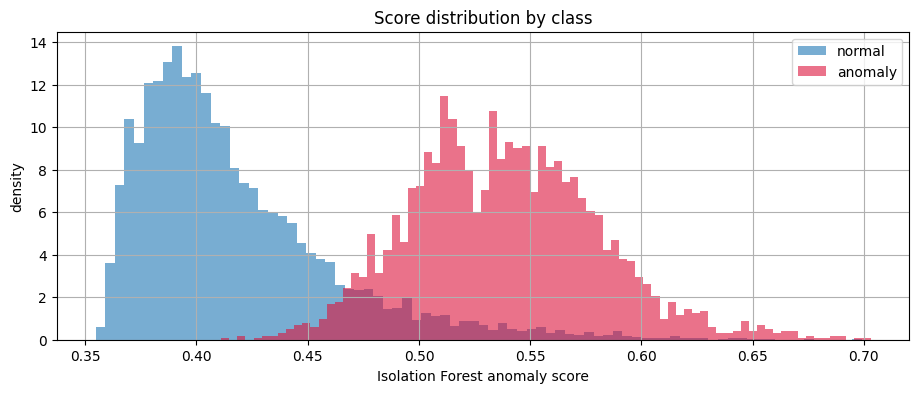

In [7]:
iforest = IsolationForestDetector(n_estimators=200, contamination=0.02, random_state=0)
iforest.fit(X[y == 0])
scores_iforest = iforest.score(X)

fig, ax = plt.subplots()
ax.hist(scores_iforest[y == 0], bins=80, alpha=0.6, label="normal", density=True)
ax.hist(scores_iforest[y == 1], bins=80, alpha=0.6, label="anomaly", density=True, color="crimson")
ax.set_xlabel("Isolation Forest anomaly score")
ax.set_ylabel("density")
ax.set_title("Score distribution by class")
ax.legend()

## 6. Autoencoder reconstruction error

*(Optional cell — requires TensorFlow.)* The autoencoder is trained on normal data only; samples it has never seen reconstruct poorly, so the per-sample MSE is used as the anomaly score.

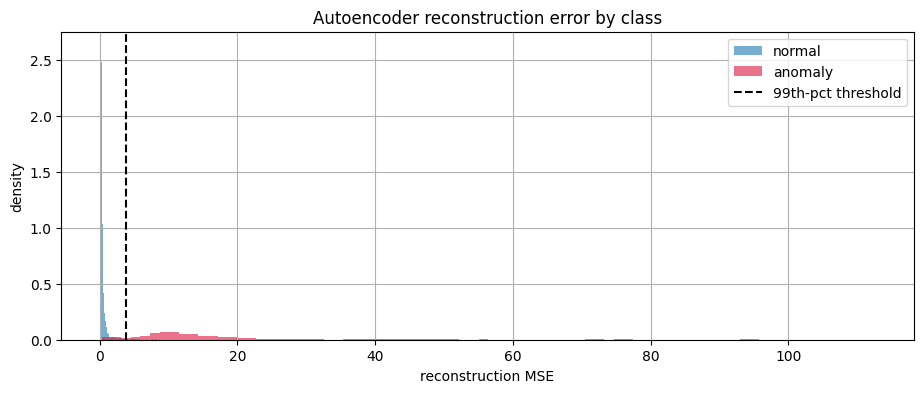

In [8]:
scores_autoencoder = None
try:
    from sentinel_stream.models.autoencoder import AutoencoderDetector

    autoencoder = AutoencoderDetector(hidden_layers=[16, 8, 4, 8, 16], epochs=10, batch_size=128)
    autoencoder.fit(X[y == 0])
    scores_autoencoder = autoencoder.score(X)

    fig, ax = plt.subplots()
    ax.hist(scores_autoencoder[y == 0], bins=80, alpha=0.6, label="normal", density=True)
    ax.hist(
        scores_autoencoder[y == 1],
        bins=80,
        alpha=0.6,
        label="anomaly",
        density=True,
        color="crimson",
    )
    ax.axvline(autoencoder.threshold, ls="--", color="black", label="99th-pct threshold")
    ax.set_xlabel("reconstruction MSE")
    ax.set_ylabel("density")
    ax.set_title("Autoencoder reconstruction error by class")
    ax.legend()
except ImportError:
    print("TensorFlow not installed — skipping the autoencoder cell.")

## 7. ROC comparison

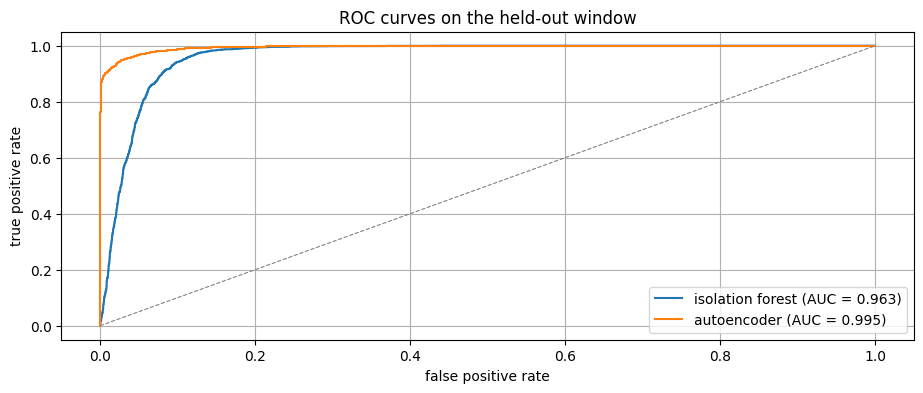

In [9]:
fig, ax = plt.subplots()
for name, scores in [("isolation forest", scores_iforest), ("autoencoder", scores_autoencoder)]:
    if scores is None:
        continue
    fpr, tpr, _ = roc_curve(y, scores)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], "--", color="grey", lw=0.8)
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC curves on the held-out window")
ax.legend()

## Takeaways

- The injected anomalies fall into three qualitatively different regimes; a single detector that handles them all is non-trivial.
- Both detectors push anomaly scores noticeably higher on the labelled positives, despite training on normal data only.
- Pairing the reconstruction-based autoencoder with a classical Isolation Forest gives a useful sanity check: when they agree, alerts are high-confidence; when they disagree, drift or distribution shift is a likely cause.
- The streaming feature transformer used here is the exact same class the FastAPI service uses at inference time — there is no train/serve skew to debug later.